In [8]:
import pandas as pd
df_raw = pd.read_csv("globalterrorismdb_0718dist.tar.bz2", compression="bz2")


df = df_raw.copy()

C:\Users\indig\AppData\Local\Temp\ipykernel_18408\2639089432.py:2: DtypeWarning: Columns (0: approxdate, 1: resolution, 2: attacktype2_txt, 3: attacktype3_txt, 4: gsubname2, 5: gname3, 6: gsubname3, 7: claimmode2_txt, 8: claimmode3_txt, 9: weaptype3_txt, 10: weapsubtype3_txt, 11: weaptype4_txt, 12: weapsubtype4_txt, 13: divert, 14: kidhijcountry, 15: ransomnote) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv("globalterrorismdb_0718dist.tar.bz2", compression="bz2")


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 136 entries, Unnamed: 0 to related
dtypes: float64(55), int64(23), str(58)
memory usage: 188.5 MB


In [16]:
df['gname'].value_counts()

gname
Unknown                                             82782
Taliban                                              7478
Islamic State of Iraq and the Levant (ISIL)          5613
Shining Path (SL)                                    4555
Farabundo Marti National Liberation Front (FMLN)     3351
                                                    ...  
Hafeez Brohi Group                                      1
Bedouin Israeli extremists                              1
Ansar Ghazwat-ul-Hind                                   1
The Owners of the White Flags                           1
Fatoni Warriors                                         1
Name: count, Length: 3537, dtype: int64

In [18]:
df[['iyear', 'imonth', 'iday', 'country_txt', 'region_txt', 'city', 'latitude', 'longitude', 'attacktype1_txt', 'targtype1_txt', 'weaptype1_txt', 'nkill', 'nwound']].head(10)

,iyear,imonth,iday,country_txt,region_txt,city,latitude,longitude,attacktype1_txt,targtype1_txt,weaptype1_txt,nkill,nwound
0,1970,7,2,Dominican Republic,Central America & Caribbean,Santo Domingo,18.456792,-69.951164,Assassination,Private Citizens & Property,Unknown,1.0,0.0
1,1970,0,0,Mexico,North America,Mexico city,19.371887,-99.086624,Hostage Taking (Kidnapping),Government (Diplomatic),Unknown,0.0,0.0
2,1970,1,0,Philippines,Southeast Asia,Unknown,15.478598,120.599741,Assassination,Journalists & Media,Unknown,1.0,0.0
3,1970,1,0,Greece,Western Europe,Athens,37.997490,23.762728,Bombing/Explosion,Government (Diplomatic),Explosives,NaN,NaN
4,1970,1,0,Japan,East Asia,Fukouka,33.580412,130.396361,Facility/Infrastructure Attack,Government (Diplomatic),Incendiary,NaN,NaN
5,1970,1,1,United States,North America,Cairo,37.005105,-89.176269,Armed Assault,Police,Firearms,0.0,0.0
6,1970,1,2,Uruguay,South America,Montevideo,-34.891151,-56.187214,Assassination,Police,Firearms,0.0,0.0
7,1970,1,2,United States,North America,Oakland,37.791927,-122.225906,Bombing/Explosion,Utilities,Explosives,0.0,0.0
8,1970,1,2,United States,North America,Madison,43.076592,-89.412488,Facility/Infrastructure Attack,Military,Incendiary,0.0,0.0
9,1970,1,3,United States,North America,Madison,43.072950,-89.386694,Facility/Infrastructure Attack,Government (General),Incendiary,0.0,0.0


<Axes: title={'center': 'Number of Terrorist Attacks by Year'}, xlabel='iyear'>

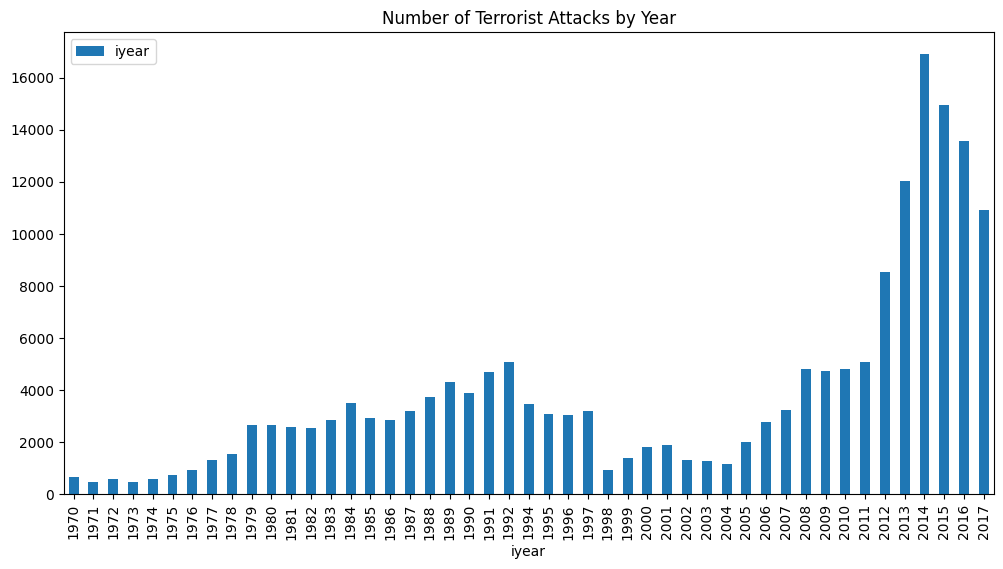

In [20]:
df.groupby('iyear').agg({'iyear':'count'}).plot(kind='bar', figsize=(12,6), title='Number of Terrorist Attacks by Year')

In [24]:
attacks = (
    df.groupby(["iyear", "country_txt"])
      .size()
      .reset_index(name="attacks")
      .sort_values("attacks", ascending=False)
)
attacks.head(10)

,iyear,country_txt,attacks
3392,2014,Iraq,3933
3596,2016,Iraq,3360
3299,2013,Iraq,2852
3492,2015,Iraq,2751
3698,2017,Iraq,2466
3322,2013,Pakistan,2215
3421,2014,Pakistan,2151
3453,2015,Afghanistan,1928
3353,2014,Afghanistan,1824
3230,2012,Pakistan,1654


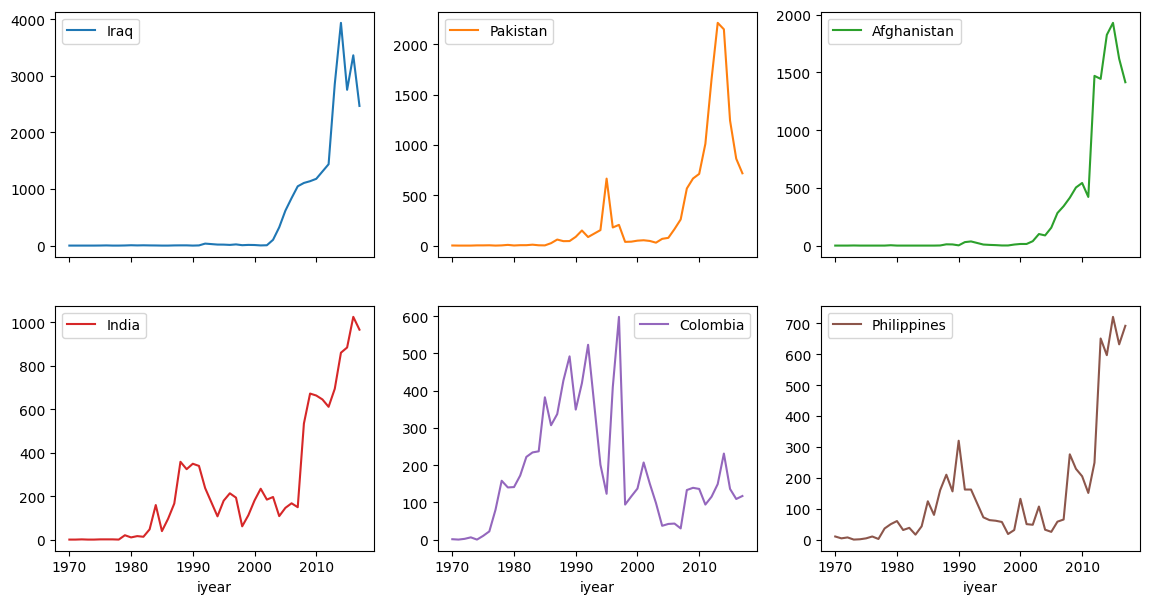

country_txt
Iraq           2014
Pakistan       2013
Afghanistan    2015
India          2016
Colombia       1997
Philippines    2015
dtype: int64


In [26]:
import matplotlib.pyplot as plt
attacks = df.groupby(["iyear", "country_txt"]).size().unstack(fill_value=0)

top = df["country_txt"].value_counts().head(6).index
attacks[top].plot(subplots=True, layout=(2, 3), figsize=(14, 7), sharex=True, sharey=False)
plt.show()

print(attacks[top].idxmax())

In [27]:
early = attacks.loc[1979:1992].sum().sort_values(ascending=False)
print(early.head(8))
print((early.head(8) / early.sum() * 100).round(1))

country_txt
Peru              5762
El Salvador       5162
Colombia          4383
United Kingdom    2238
Chile             2197
India             2173
Spain             1894
Nicaragua         1812
dtype: int64
country_txt
Peru              12.1
El Salvador       10.9
Colombia           9.2
United Kingdom     4.7
Chile              4.6
India              4.6
Spain              4.0
Nicaragua          3.8
dtype: float64


In [28]:
print(df[["nkill", "nwound"]].isna().mean().round(3))

df["casualties"] = df[["nkill", "nwound"]].sum(axis=1)   # a missing count is treated as 0

by_year = df.groupby("iyear").agg(
    incidents=("casualties", "size"),
    casualties=("casualties", "sum"),
)
by_year.describe().round(0)

nkill     0.057
nwound    0.090
dtype: float64


,incidents,casualties
count,47.0,47.0
mean,3866.0,19909.0
std,3837.0,20603.0
min,471.0,255.0
25%,1364.0,8333.0
50%,2870.0,13691.0
75%,4504.0,23340.0
max,16903.0,85618.0


Pearson:  0.95
Spearman: 0.83


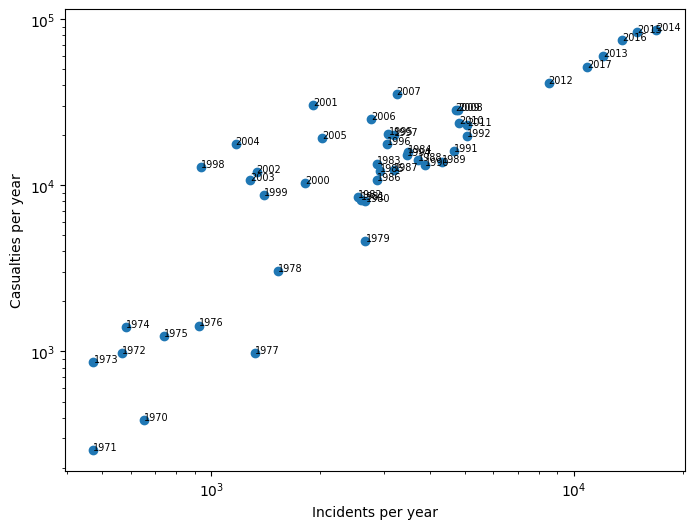

iyear
1971    0.5
1970    0.6
1977    0.7
1976    1.5
1975    1.7
Name: per_incident, dtype: float64
iyear
2005     9.5
2007    10.9
1998    13.8
2004    15.2
2001    16.0
Name: per_incident, dtype: float64


In [29]:
by_year["per_incident"] = by_year["casualties"] / by_year["incidents"]

print("Pearson: ", round(by_year["incidents"].corr(by_year["casualties"]), 2))
print("Spearman:", round(by_year["incidents"].corr(by_year["casualties"], method="spearman"), 2))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(by_year["incidents"], by_year["casualties"])
for yr, r in by_year.iterrows():
    ax.annotate(yr, (r["incidents"], r["casualties"]), fontsize=7)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Incidents per year"); ax.set_ylabel("Casualties per year")
plt.show()

print(by_year["per_incident"].sort_values().head(5).round(1))
print(by_year["per_incident"].sort_values().tail(5).round(1))


In [30]:
cols = ["iyear", "country_txt", "nkill", "nwound", "casualties"]
df.nlargest(10, "casualties")[cols]

,iyear,country_txt,nkill,nwound,casualties
73126,2001,United States,1384.0,8190.0,9574.0
73127,2001,United States,1383.0,8191.0,9574.0
58841,1995,Japan,13.0,5500.0,5513.0
68071,1998,Kenya,224.0,4000.0,4224.0
133518,2014,Iraq,1570.0,NaN,1570.0
159773,2016,Iraq,3.0,1500.0,1503.0
61548,1996,Sri Lanka,90.0,1272.0,1362.0
55934,1994,Rwanda,1180.0,0.0,1180.0
85682,2008,Chad,160.0,1001.0,1161.0
76953,2004,Russia,344.0,727.0,1071.0


                                     attacks  share_%
attacktype1_txt                                      
Bombing/Explosion                      88255     48.6
Armed Assault                          42669     23.5
Assassination                          19312     10.6
Hostage Taking (Kidnapping)            11158      6.1
Facility/Infrastructure Attack         10356      5.7
Unknown                                 7276      4.0
Unarmed Assault                         1015      0.6
Hostage Taking (Barricade Incident)      991      0.5
Hijacking                                659      0.4


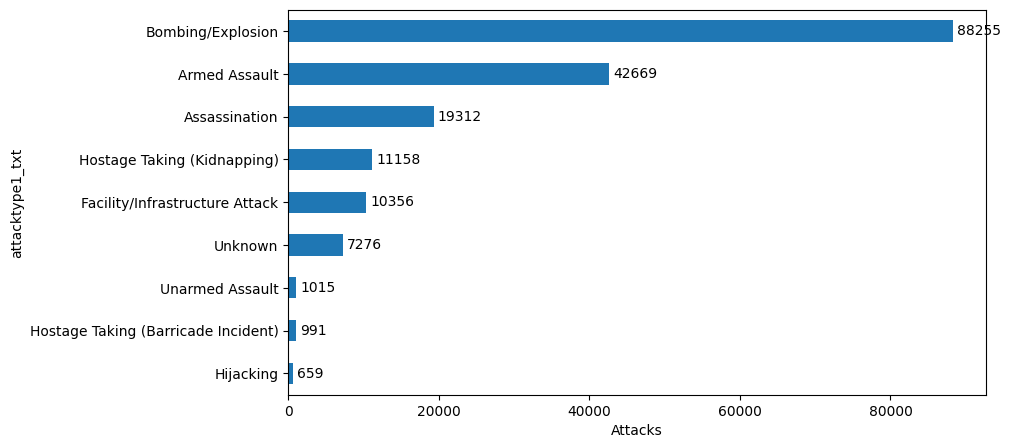

In [31]:
attack_counts = df["attacktype1_txt"].value_counts()
attack_share = (attack_counts / attack_counts.sum() * 100).round(1)
print(pd.DataFrame({"attacks": attack_counts, "share_%": attack_share}))

ax = attack_counts.sort_values().plot(kind="barh", figsize=(9, 5))
ax.bar_label(ax.containers[0], padding=3)
ax.set_xlabel("Attacks")
plt.show()

In [32]:
attack_counts = df["attacktype1_txt"].value_counts()
attack_share = (attack_counts / attack_counts.sum() * 100).round(1)
print(pd.DataFrame({"attacks": attack_counts, "share_%": attack_share}))

                                     attacks  share_%
attacktype1_txt                                      
Bombing/Explosion                      88255     48.6
Armed Assault                          42669     23.5
Assassination                          19312     10.6
Hostage Taking (Kidnapping)            11158      6.1
Facility/Infrastructure Attack         10356      5.7
Unknown                                 7276      4.0
Unarmed Assault                         1015      0.6
Hostage Taking (Barricade Incident)      991      0.5
Hijacking                                659      0.4


177134 (2.5% of attacks have no coordinates)
True False


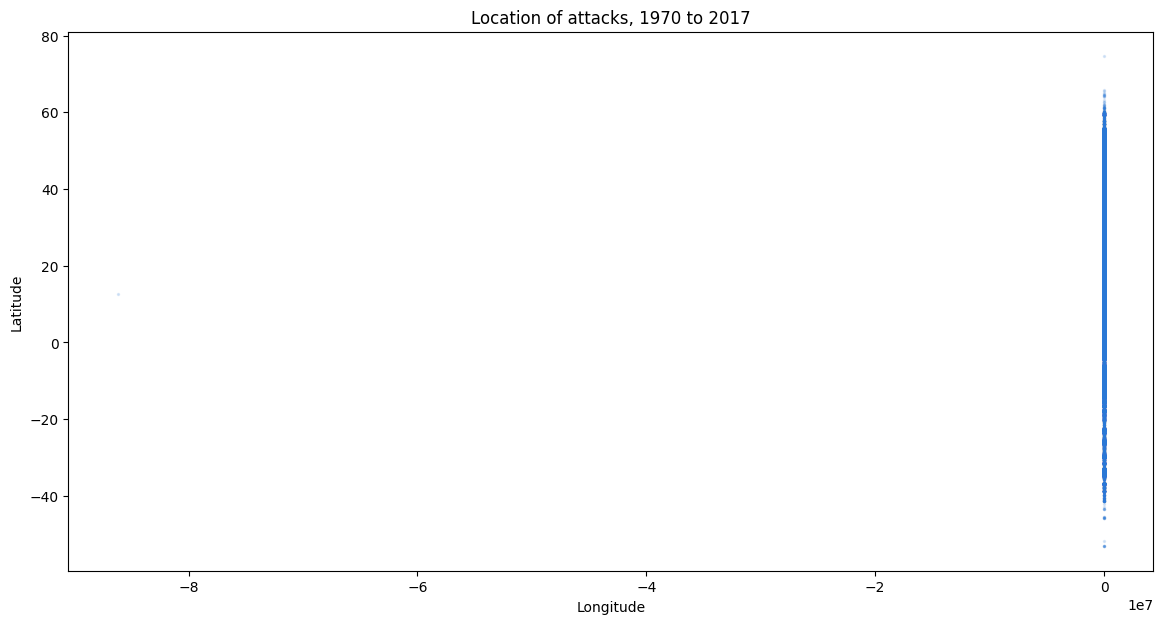

In [33]:
geo = df.dropna(subset=["latitude", "longitude"])
print(len(geo), f"({1 - len(geo) / len(df):.1%} of attacks have no coordinates)")
print(geo["latitude"].between(-90, 90).all(), geo["longitude"].between(-180, 180).all())

fig, ax = plt.subplots(figsize=(14, 7))
ax.scatter(geo["longitude"], geo["latitude"], s=2, alpha=0.15, color="#2a78d6")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Location of attacks, 1970 to 2017")
plt.show()

In [34]:
bad = geo[~geo["longitude"].between(-180, 180)]
print(len(bad))
bad[["eventid", "iyear", "country_txt", "city", "latitude", "longitude"]]

1


,eventid,iyear,country_txt,city,latitude,longitude
17658,198212240004,1982,Nicaragua,Valle El Oregano,12.643985,-86185896.0


In [35]:
geo = geo.copy()
geo.loc[bad.index, "longitude"] = geo.loc[bad.index, "longitude"] / 1_000_000
print(geo["longitude"].between(-180, 180).all())

True


1 row(s) with impossible longitude excluded


,eventid,iyear,country_txt,city,latitude,longitude
17658,198212240004,1982,Nicaragua,Valle El Oregano,12.643985,-86185896.0


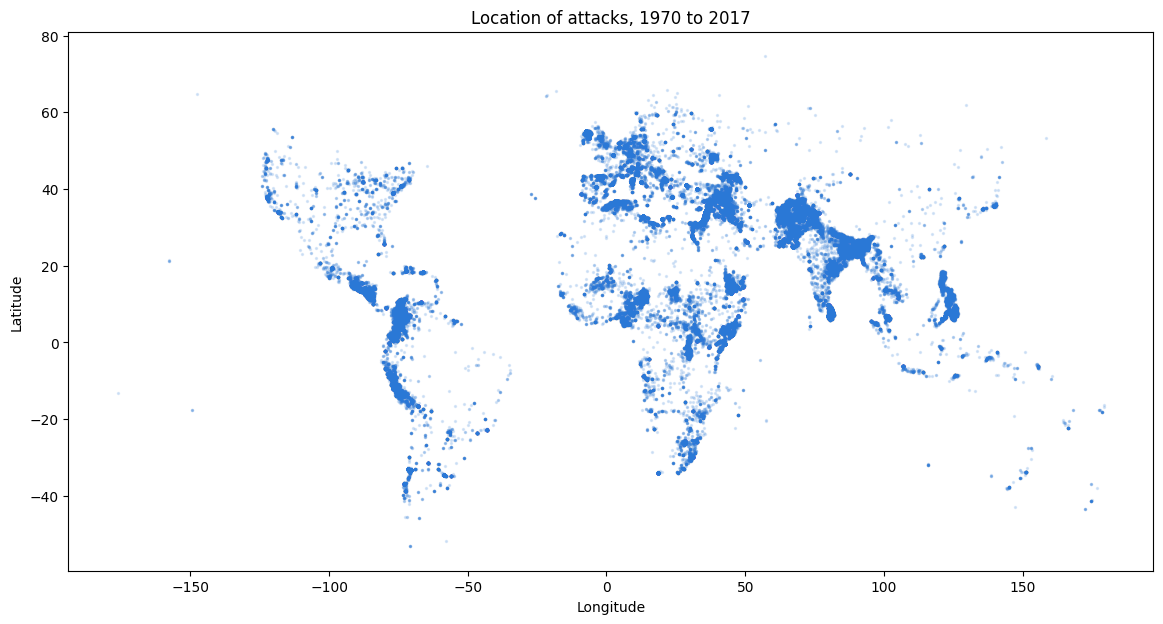

In [37]:
geo = df.dropna(subset=["latitude", "longitude"])
bad = geo[~geo["longitude"].between(-180, 180)]
geo = geo[geo["longitude"].between(-180, 180)]

print(len(bad), "row(s) with impossible longitude excluded")
display(bad[["eventid", "iyear", "country_txt", "city", "latitude", "longitude"]])

fig, ax = plt.subplots(figsize=(14, 7))
ax.scatter(geo["longitude"], geo["latitude"], s=2, alpha=0.15, color="#2a78d6")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Location of attacks, 1970 to 2017")
plt.show()

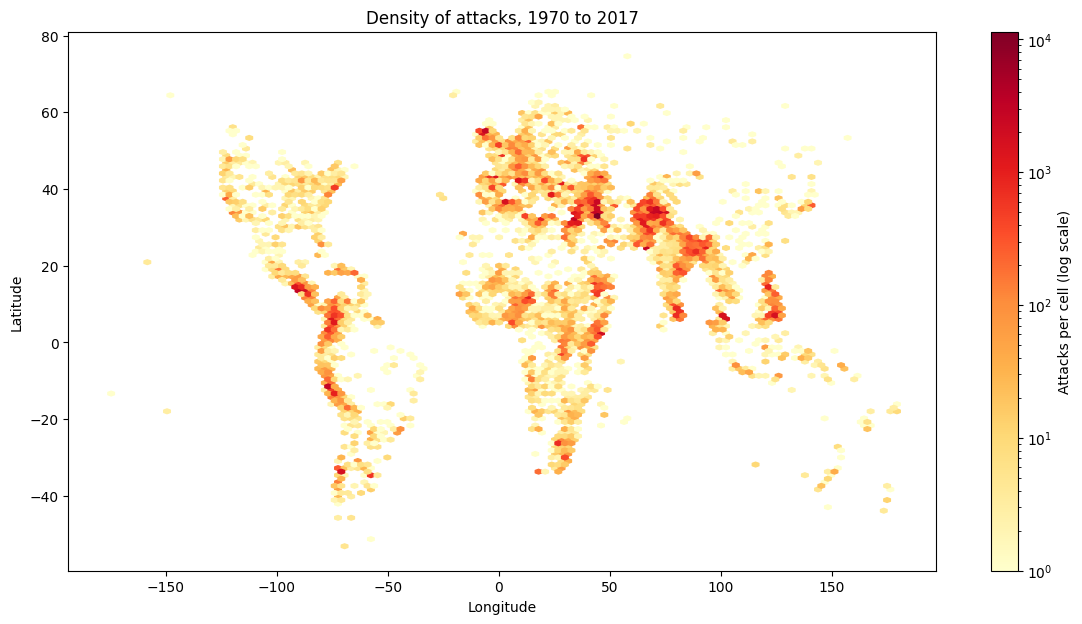

In [38]:
fig, ax = plt.subplots(figsize=(14, 7))
hb = ax.hexbin(geo["longitude"], geo["latitude"], gridsize=120, bins="log", cmap="YlOrRd", mincnt=1)
fig.colorbar(hb, label="Attacks per cell (log scale)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Density of attacks, 1970 to 2017")
plt.show()